<a href="https://colab.research.google.com/github/elangbijak4/multi-agent-AI/blob/main/Optimasi4_Integrasi_Model_DT_NB_LogReg_SVM_dalam_satu_Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


[MODE 1] Single Brain Selection
Tree Accuracy: 0.8267
Bayes Accuracy: 0.7800
Linear Accuracy: 0.8067
SVM Accuracy: 0.8967
Selected Brain: SVM

[MODE 2] Contextual Brain Switching
Accuracy: 0.8133

[MODE 3] Ensemble Brain
Accuracy: 0.8733

[MODE 4] Meta-Agent Mode Selection
Mode performances:
Single Brain: 0.8967
Contextual Switching: 0.8133
Ensemble: 0.8733

Meta-Agent selects: Single Brain


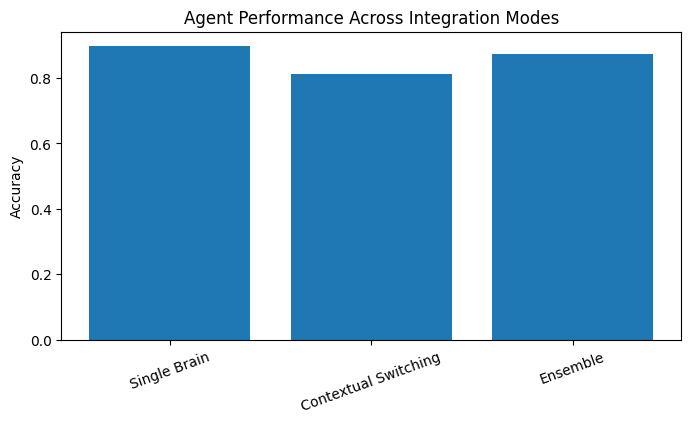

In [5]:
# ============================================================
# UNIFIED INTELLIGENT AGENT WITH MULTIPLE BRAIN INTEGRATION MODES
# Modes:
# 1. Single Brain Selection
# 2. Contextual Brain Switching
# 3. Ensemble Brain
# 4. Meta-Agent Mode Selection
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# ------------------------------------------------------------
# 1. ENVIRONMENT
# ------------------------------------------------------------
X, y = make_classification(
    n_samples=1000,
    n_features=8,
    n_informative=5,
    n_redundant=0,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ------------------------------------------------------------
# 2. BRAIN FACTORY
# ------------------------------------------------------------
def create_brains():
    return {
        "Tree": DecisionTreeClassifier(max_depth=5),
        "Bayes": GaussianNB(),
        "Linear": LogisticRegression(max_iter=1000),
        "SVM": SVC(probability=True)
    }

# ------------------------------------------------------------
# 3. AGENT DEFINITION
# ------------------------------------------------------------
class IntelligentAgent:

    def __init__(self, brains):
        self.brains = brains
        self.mode_performance = {}

    # ----------------------
    # Core agent loop
    # ----------------------
    def perceive(self, X):
        return X

    def optimize_brains(self, X, y):
        for brain in self.brains.values():
            brain.fit(X, y)

    def act(self, brain, X):
        return brain.predict(X)

    def evaluate(self, y_pred, y_true):
        return accuracy_score(y_true, y_pred)

    # ----------------------
    # MODE 1: Single Brain
    # ----------------------
    def mode_single_brain(self):
        print("\n[MODE 1] Single Brain Selection")

        scores = {}
        for name, brain in self.brains.items():
            y_pred = self.act(brain, X_test)
            scores[name] = self.evaluate(y_pred, y_test)
            print(f"{name} Accuracy: {scores[name]:.4f}")

        best = max(scores, key=scores.get)
        self.mode_performance["Single Brain"] = scores[best]
        print(f"Selected Brain: {best}")

    # ----------------------
    # MODE 2: Contextual Switching
    # ----------------------
    def mode_contextual_switching(self):
        print("\n[MODE 2] Contextual Brain Switching")

        mid = X_test.shape[1] // 2
        preds = []

        for x in X_test:
            if np.mean(x[:mid]) > 0:
                preds.append(self.brains["Tree"].predict(x.reshape(1,-1))[0])
            else:
                preds.append(self.brains["Linear"].predict(x.reshape(1,-1))[0])

        acc = self.evaluate(np.array(preds), y_test)
        self.mode_performance["Contextual Switching"] = acc
        print(f"Accuracy: {acc:.4f}")

    # ----------------------
    # MODE 3: Ensemble
    # ----------------------
    def mode_ensemble(self):
        print("\n[MODE 3] Ensemble Brain")

        prob_sum = np.zeros(len(X_test))

        for brain in self.brains.values():
            prob_sum += brain.predict_proba(X_test)[:,1]

        ensemble_pred = (prob_sum / len(self.brains)) > 0.5
        acc = self.evaluate(ensemble_pred.astype(int), y_test)
        self.mode_performance["Ensemble"] = acc
        print(f"Accuracy: {acc:.4f}")

    # ----------------------
    # MODE 4: Meta-Agent
    # ----------------------
    def mode_meta_agent(self):
        print("\n[MODE 4] Meta-Agent Mode Selection")

        performances = self.mode_performance
        best_mode = max(performances, key=performances.get)

        print("Mode performances:")
        for mode, score in performances.items():
            print(f"{mode}: {score:.4f}")

        print(f"\nMeta-Agent selects: {best_mode}")

# ------------------------------------------------------------
# 4. RUN AGENT LIFE CYCLE
# ------------------------------------------------------------
brains = create_brains()
agent = IntelligentAgent(brains)

agent.optimize_brains(X_train, y_train)

agent.mode_single_brain()
agent.mode_contextual_switching()
agent.mode_ensemble()
agent.mode_meta_agent()

# ------------------------------------------------------------
# 5. VISUAL SUMMARY
# ------------------------------------------------------------
plt.figure(figsize=(8,4))
plt.bar(agent.mode_performance.keys(), agent.mode_performance.values())
plt.xticks(rotation=20)
plt.ylabel("Accuracy")
plt.title("Agent Performance Across Integration Modes")
plt.show()
